<a href="https://colab.research.google.com/github/Waffle0823/Supervised-Learning/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install keras

In [6]:
!pip install np_utils

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9252 - loss: 0.2441 - val_accuracy: 0.9701 - val_loss: 0.1016
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9654 - loss: 0.1109 - val_accuracy: 0.9719 - val_loss: 0.0919
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9737 - loss: 0.0846 - val_accuracy: 0.9745 - val_loss: 0.0865
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9790 - loss: 0.0660 - val_accuracy: 0.9763 - val_loss: 0.0861
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9814 - loss: 0.0573 - val_accuracy: 0.9764 - val_loss: 0.0864


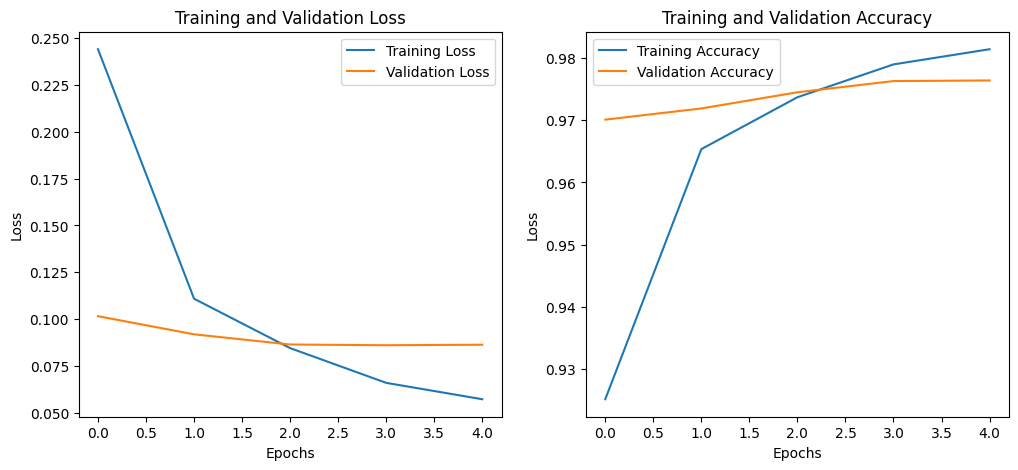

In [41]:
from keras.utils import to_categorical
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout
import matplotlib.pyplot as plt
import numpy as np

# save mnist.load_data() result tuple as (x_train, y_train) (x_test, y_test)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Reshape x_train data as 784 length arrays of 60000 datasets
# Convert pixel data as float32
# Normalize data by deviding 255
x_train = x_train.reshape(60000, 784).astype('float32') / 255.0

# Reshape x_test data as 784 length arrays of 60000 datasets
# Convert pixel data as float32
# Normalize data by deviding 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255.0

# One Hot Encoding (Convert data from number to array)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# define plot_sample_images function
def plot_sample_images(x_data, y_data, num_classes=10):
  # Create a new top level container
  plt.figure(figsize=(10, 10))

  # Iterate for num_classes
  for i in range(num_classes):
    # Get index of y_data[:, i] == 1[0]
    idxs = np.where(y_data[:, i] == 1)[0]
    idx = np.random.choice(idxs)

    # Get image data from x_data[idx] and reshape data to 28 by 28
    img = x_data[idx].reshape(28, 28)

    plt.subplot(1, num_classes, i+1)

    # Create readable image
    plt.imshow(img, cmap='gray')
    plt.axis('off')
    plt.title(f"Label: {i}")

  # Show image
  plt.show()

# for i in range(10):
#   plot_sample_images(x_train, y_train)

# 0~50000 is train data and 50001~end
x_train, x_val = x_train[:50000], x_train[50000:]
y_train, y_val = y_train[:50000], y_train[50000:]

model = Sequential()

# Input
model.add(Dense(512, input_dim=28*28, activation='relu'))
model.add(Dropout(0.2))

# Hide
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.2))

# Output
model.add(Dense(10, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

hist = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_val, y_val))

plt.figure(figsize=(12, 5))

# Figure of Training and Validation Loss
plt.subplot(1, 2, 1)
plt.plot(hist.history['loss'], label="Training Loss")
plt.plot(hist.history['val_loss'], label="Validation Loss")
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')

plt.subplot(1, 2, 2)
plt.plot(hist.history['accuracy'], label="Training Accuracy")
plt.plot(hist.history['val_accuracy'], label="Validation Accuracy")
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Accuracy')

plt.show()